In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

0.0 8.716326236724854
0.10101010101010101 8.670355081558228
0.20202020202020202 7.125128984451294
0.30303030303030304 8.637495040893555
0.40404040404040403 8.658852815628052
0.5050505050505051 7.137046813964844
0.6060606060606061 8.667511940002441
0.7070707070707071 8.639016389846802
0.8080808080808081 8.63132381439209
0.9090909090909091 7.125789403915405
1.0101010101010102 8.685077667236328
1.1111111111111112 8.717221021652222
1.2121212121212122 8.678048372268677
1.3131313131313131 7.112528324127197
1.4141414141414141 8.636518716812134
1.5151515151515151 8.710982322692871
1.6161616161616161 8.685667276382446
1.7171717171717171 7.110854864120483
1.8181818181818181 8.67000150680542
1.9191919191919191 8.735994577407837
2.0202020202020203 7.18404746055603
2.121212121212121 8.679959297180176
2.2222222222222223 8.70613169670105
2.323232323232323 8.699955940246582
2.4242424242424243 7.221682786941528
2.525252525252525 8.722808837890625
2.6262626262626263 8.731971979141235
2.727272727272727 8

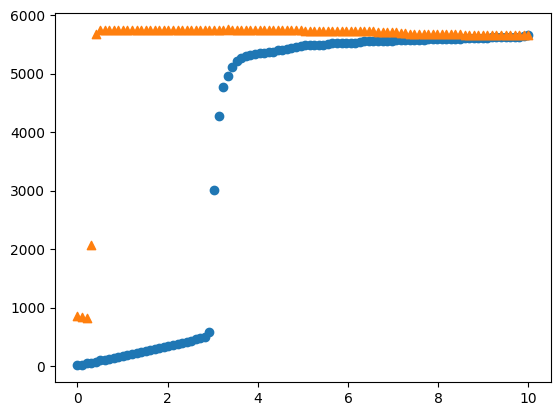

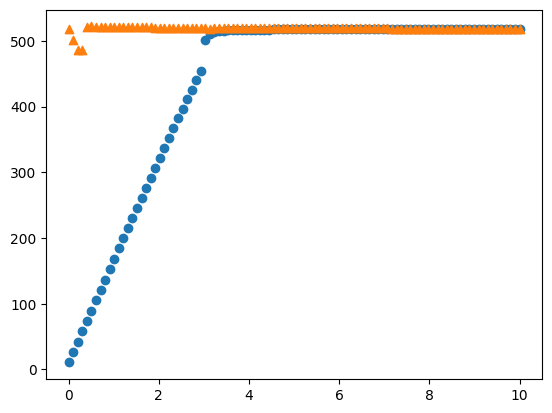

In [2]:
n=500
m=500
G = nx.gnm_random_graph(n, m)
edges = list(G.edges())
t = sum(nx.triangles(G).values()) // 3
its = 500000
burn_in = 50000
up_tris = []
down_tris = []
up_vars = []
down_vars = []
deg_sq_sum = sum(d**2 for _, d in G.degree())

b_vals = np.linspace(0, 10, 100)
import time
for b in b_vals:
    total_edges = 0
    total_tris = 0
    total_var = 0
    start_time = time.time()
    for _ in range(its):
        current_edge = edges[np.random.randint(len(edges))]
        new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        while new_edge[0] == new_edge[1] or G.has_edge(new_edge[0], new_edge[1]):
            new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        
        deg_c0 = len(G[current_edge[0]])
        deg_c1 = len(G[current_edge[1]])
        deg_n0 = len(G[new_edge[0]])
        deg_n1 = len(G[new_edge[1]])

        delta_deg_sq = 2*(deg_n0 + deg_n1 - deg_c0 - deg_c1)+4
        delta_t = len(list(nx.common_neighbors(G, new_edge[0], new_edge[1]))) - len(list(nx.common_neighbors(G, current_edge[0], current_edge[1])))
        G.remove_edge(*current_edge)
        G.add_edge(*new_edge)
        
        dH = b * delta_t
        if np.log(np.random.uniform()) <= dH:
            t += delta_t
            deg_sq_sum += delta_deg_sq
            edges.remove(current_edge)
            edges.append(new_edge)
        else:
            # revert
            G.remove_edge(*new_edge)
            G.add_edge(*current_edge)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t
            total_var += deg_sq_sum/n - (2*m/n)**2
    print(b, time.time() - start_time)
    up_tris.append(total_tris / (its-burn_in))
    up_vars.append(total_var / (its-burn_in))

for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0
    total_var = 0
    start_time = time.time()
    for _ in range(its):
        current_edge = edges[np.random.randint(len(edges))]
        new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        while new_edge[0] == new_edge[1] or G.has_edge(new_edge[0], new_edge[1]):
            new_edge = (np.random.randint(0, n), np.random.randint(0, n))
        
        deg_c0 = len(G[current_edge[0]])
        deg_c1 = len(G[current_edge[1]])
        deg_n0 = len(G[new_edge[0]])
        deg_n1 = len(G[new_edge[1]])

        delta_deg_sq = 2*(deg_n0 + deg_n1 - deg_c0 - deg_c1)+4
        delta_t = len(list(nx.common_neighbors(G, new_edge[0], new_edge[1]))) - len(list(nx.common_neighbors(G, current_edge[0], current_edge[1])))
        G.remove_edge(*current_edge)
        G.add_edge(*new_edge)
        
        dH = b * delta_t
        if np.log(np.random.uniform()) <= dH:
            t += delta_t
            deg_sq_sum += delta_deg_sq
            edges.remove(current_edge)
            edges.append(new_edge)
        else:
            # revert
            G.remove_edge(*new_edge)
            G.add_edge(*current_edge)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t
            total_var += deg_sq_sum/n - (2*m/n)**2
    print(b, time.time() - start_time)
    down_tris.append(total_tris / (its-burn_in))
    down_vars.append(total_var / (its-burn_in))


plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_vars, label='upsweep', marker = 'o') 
plt.scatter(b_vals[::-1], down_vars, label = 'downsweep', marker = '^')
plt.show()
